In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Ingestion
df = pd.read_csv("data/StudentsPerformance.csv")

# Clean column names
df.columns = [c.strip().lower().replace(" ","_") for c in df.columns]
for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median() if pd.api.types.is_numeric_dtype(df[c]) else df[c].mode()[0])
df["overall_avg"] = df[["math_score","reading_score","writing_score"]].mean(axis=1)



# Check missing values
print("Missing values before preprocessing:")
print(df.isnull().sum())

# Handle missing values
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Check dataset
print("\nDataset shape:", df.shape)
df.head()





Missing values before preprocessing:
gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
overall_avg                    0
dtype: int64

Missing values after preprocessing:
gender                         0
race/ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
overall_avg                    0
dtype: int64

Dataset shape: (1000, 9)


,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,overall_avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [ ]:
# Now working on V1-V5
## For each Figure size i changed from 800×600 px to 1200×800 px to make it more readable and clear.


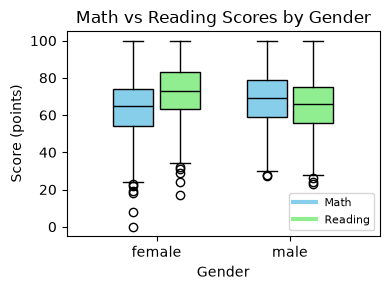

In [40]:
# V1 — Gender boxplots

import numpy as np
import matplotlib.pyplot as plt

genders = df["gender"].unique()

math_data = [
    df[df["gender"] == gender]["math_score"]
    for gender in genders
]

reading_data = [
    df[df["gender"] == gender]["reading_score"]
    for gender in genders
]

# Positions for the genders
positions = np.arange(len(genders))

fig, ax = plt.subplots(figsize=(1200/300, 900/300), dpi=100)

width = 0.35

# Math boxplots
ax.boxplot(
    math_data,
    positions=positions - width/2,
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="black")
)

# Reading boxplots
ax.boxplot(
    reading_data,
    positions=positions + width/2,
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
    medianprops=dict(color="black")
)

# X-axis
ax.set_xticks(positions)
ax.set_xticklabels(genders)

# Labels and title
ax.set_xlabel("Gender")
ax.set_ylabel("Score (points)")
ax.set_title("Math vs Reading Scores by Gender")

# Legend
ax.legend(
    [
        plt.Line2D([0], [0], color="skyblue", linewidth=3),
        plt.Line2D([0], [0], color="lightgreen", linewidth=3)
    ],
    ["Math", "Reading"],
    fontsize=8
)

plt.tight_layout()

plt.show()





In [4]:
#V1 stat
df.groupby("gender")[["math_score", "reading_score"]].agg(
    ["mean", "median", "std"]
).round(2)

math_score               reading_score              
             mean median    std          mean median    std
gender                                                     
female      63.63   65.0  15.49         72.61   73.0  14.38
male        68.73   69.0  14.36         65.47   66.0  13.93

test_preparation_course
completed    69.695531
none         64.077882
Name: math_score, dtype: float64


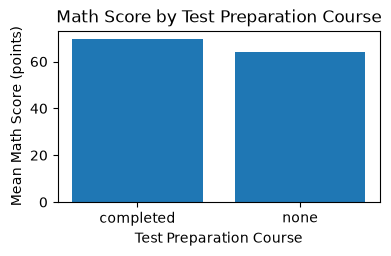

In [ ]:
# V2 — Test preparation impact on math

prep_means = df.groupby(
    "test_preparation_course"
)["math_score"].mean()

print(prep_means)

fig, ax = plt.subplots(figsize=(1200/300, 800/300))

ax.bar(
    prep_means.index,
    prep_means.values
)

ax.set_xlabel("Test Preparation Course")
ax.set_ylabel("Mean Math Score (points)")
ax.set_title("Math Score by Test Preparation Course")

plt.tight_layout()


plt.show()

In [34]:
df.groupby("test_preparation_course")["math_score"].agg(
    ["mean", "median", "std", "count"]
).round(2)

,mean,median,std,count
test_preparation_course,,,,
completed,69.70,69.0,14.44,358
none,64.08,64.0,15.19,642


          lunch  math_score  reading_score  writing_score
0  free/reduced   58.921127      64.653521      63.022535
1      standard   70.034109      71.654264      70.823256


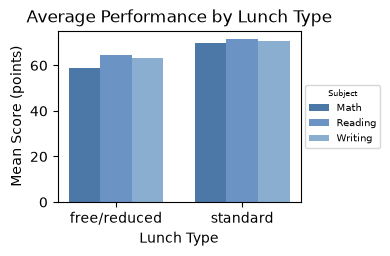

In [38]:
# V3 — Lunch type and average performance

lunch_means = (
    df.groupby("lunch")[["math_score", "reading_score", "writing_score"]]
    .mean()
    .reset_index()
)

print(lunch_means)

fig, ax = plt.subplots(figsize=(1200/300, 800/300), dpi=100)

x = np.arange(len(lunch_means))
width = 0.25

ax.bar(
    x - width,
    lunch_means["math_score"],
    width,
    label="Math",
    color="#4C78A8"
)

ax.bar(
    x,
    lunch_means["reading_score"],
    width,
    label="Reading",
     color="#6B93C4"
      
)

ax.bar(
    x + width,
    lunch_means["writing_score"],
    width,
    label="Writing",
     color="#89AED0"
)

ax.set_xlabel("Lunch Type")
ax.set_ylabel("Mean Score (points)")
ax.set_title("Average Performance by Lunch Type")

ax.set_xticks(x)
ax.set_xticklabels(lunch_means["lunch"])

ax.legend(title="Subject",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=7,
        title_fontsize=6,
        frameon=True,
        borderpad=0.4,
        labelspacing=0.5,)

plt.tight_layout()
plt.show()

In [ ]:
df.groupby("lunch")["overall_avg"].agg(
    ["mean", "median", "std", "count"]
).round(2)

               math_score  reading_score  writing_score
math_score       1.000000       0.817580       0.802642
reading_score    0.817580       1.000000       0.954598
writing_score    0.802642       0.954598       1.000000


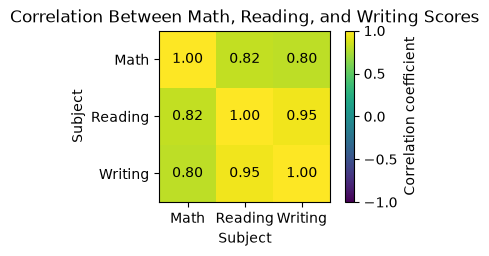

In [ ]:
# V4 — Subject correlations

subjects = [
    "math_score",
    "reading_score",
    "writing_score"
]

corr_matrix = df[subjects].corr()

print(corr_matrix)

fig, ax = plt.subplots(figsize=(1200/300, 800/300))

im = ax.imshow(
    corr_matrix,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(3))
ax.set_yticks(range(3))

ax.set_xticklabels(
    ["Math", "Reading", "Writing"]
)

ax.set_yticklabels(
    ["Math", "Reading", "Writing"]
)

ax.set_xlabel("Subject")
ax.set_ylabel("Subject")
ax.set_title("Correlation Between Math, Reading, and Writing Scores")

# Add correlation numbers
for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(
    im,
    ax=ax,
    label="Correlation coefficient"
)

plt.tight_layout()

plt.show()

In [35]:
df[
    ["math_score", "reading_score", "writing_score"]
].corr().round(2)

,math_score,reading_score,writing_score
math_score,1.00,0.82,0.80
reading_score,0.82,1.00,0.95
writing_score,0.80,0.95,1.00


completed: slope = 0.840, intercept = 7.597, n = 358
none: slope = 0.861, intercept = 6.766, n = 642


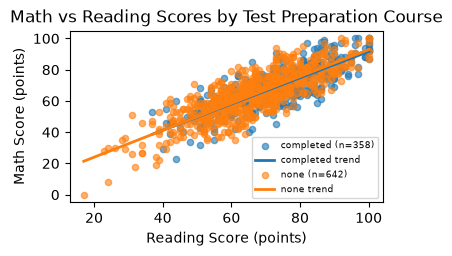

In [30]:
# V5 — Math vs Reading with trend lines

fig, ax = plt.subplots(figsize=(1200/300, 800/300))

groups = ["completed", "none"]

for group in groups:

    group_df = df[
        df["test_preparation_course"] == group
    ]

    x = group_df["reading_score"]
    y = group_df["math_score"]

    # Scatter points
    ax.scatter(
        x,
        y,
        alpha=0.6,
        s=20,
        label=f"{group} (n={len(group_df)})"
    )

    # Best-fit straight line
    slope, intercept = np.polyfit(x, y, 1)

    x_line = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_line = slope * x_line + intercept

    ax.plot(
        x_line,
        y_line,
        linewidth=2,
        label=f"{group} trend"
    )

    print(
        f"{group}: "
        f"slope = {slope:.3f}, "
        f"intercept = {intercept:.3f}, "
        f"n = {len(group_df)}"
    )

ax.set_xlabel("Reading Score (points)")
ax.set_ylabel("Math Score (points)")
ax.set_title(
    "Math vs Reading Scores by Test Preparation Course"
)

ax.legend(fontsize=6.5,
    markerscale=1,
    handlelength=2,
    labelspacing=0.5)

plt.tight_layout()

plt.savefig(
    "V5_math_reading_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
df.groupby("test_preparation_course").apply(
    lambda x: x["reading_score"].corr(x["math_score"]),
    include_groups=False
).round(3)

test_preparation_course
completed    0.793
none         0.820
dtype: float64